# AEX Index Hurst Exponent Estimation

Uses Oxford-Man Realized Volatility AEX rv5 data with a 5-year window for Hurst estimation. Compare with China market (CSI 300) to assess rough volatility modeling applicability.

## 1. Imports and Data Loading

In [1]:
import sys
sys.path.append('../models_en')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from HurstEstimator import HurstEstimator

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['Arial Unicode MS']

In [2]:
# Load Oxford-Man data, filter AEX index
df_raw = pd.read_csv('../data/oxfordmanrealizedvolatilityindices.csv')
df_aex = df_raw[df_raw['Symbol'] == '.AEX'].copy()

# Parse dates to naive datetime for slicing
date_col = df_aex.columns[0]
df_aex['date'] = pd.to_datetime(df_aex[date_col], utc=True).dt.tz_localize(None)
df_aex = df_aex.set_index('date').sort_index()

# Filter invalid rv5 (0 or negative)
df_aex = df_aex[df_aex['rv5'] > 1e-12]

# 5-year window: 2013-01-01 ~ 2018-06-27
df = df_aex.loc['2013-01-01':'2018-06-27'].copy()

print(f"Data range: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"Trading days: {len(df)}")

Data range: 2013-01-02 ~ 2018-06-26
Trading days: 1401


## 2. Hurst Exponent Estimation (q=2 Variogram Regression)

Input: log σ = 0.5 * log(rv5), consistent with HurstEstimator.

In [3]:
hurst = HurstEstimator()
log_vol_series = 0.5 * np.log(df['rv5'])  # log(σ)

START_IDX = 500  # Use first 500 days for parameter estimation
H, h_info = hurst.estimate_hurst_variogram(log_vol_series[:START_IDX], q=2.0)

print(f"Hurst H = {H:.4f} (R² = {h_info['r_squared']:.4f})")
print(f"2nd moment regression intercept {h_info['intercept']:.4f}, ν² = {np.exp(h_info['intercept'])}")

nu_sq = np.exp(h_info['intercept'])

Hurst H = 0.0912 (R² = 0.8091)
2nd moment regression intercept -2.2261, ν² = 0.10794596682105004


## 3. Variogram Visualization

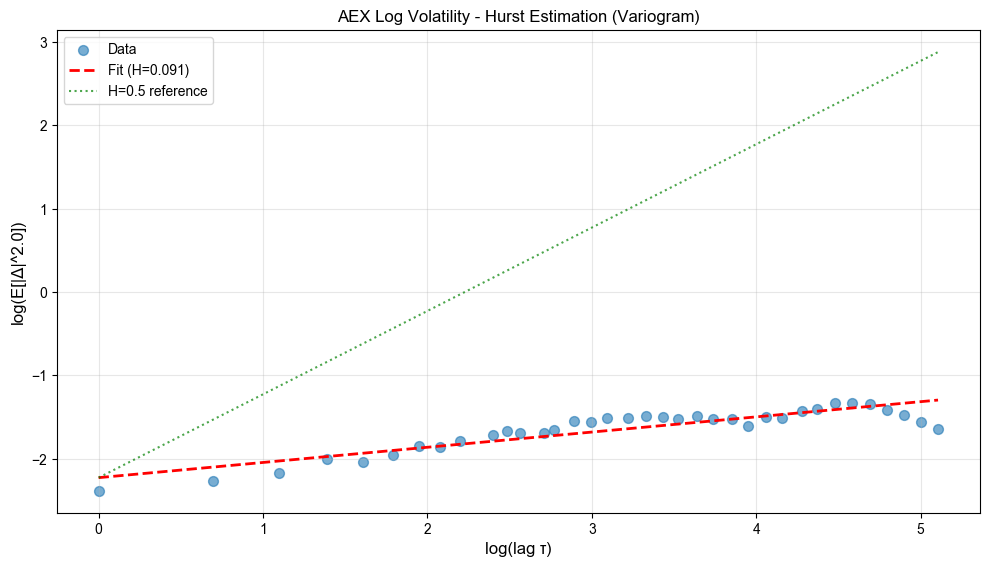

In [4]:
hurst.plot_variogram(log_vol_series[:START_IDX], q=2.0)
plt.title('AEX Log Volatility - Hurst Estimation (Variogram)')
plt.show()

## 4. Roughness Test (Optional)

In [5]:
test_result = hurst.estimate_hurst_roughness_test(log_vol_series[:START_IDX])
print(f"H = {test_result['H']:.3f}, is_rough: {test_result['is_rough']}")

H = 0.091, is_rough: True
